# 03 Model Training — Social Media Misinformation Detector (SMD)

This notebook is **standalone**. It does not depend on your `data_analysis.ipynb` or `feature_extraction.ipynb` notebook variables.

It can work in two ways:

1. If `feature_dataset.csv` exists, it will use extracted features such as `sensational_score`, `hedging_score`, and `sentiment_compound`.
2. If `feature_dataset.csv` does not exist, it will directly load the raw LIAR dataset file `train.tsv` and train a text-only model.

Final output:
- Trained model
- Evaluation metrics
- Confusion matrix
- Prediction + evidence report function
- Saved `.pkl` model file


In [1]:
# Install only if needed
# !pip install pandas numpy scikit-learn matplotlib joblib

## 1. Import Libraries

In [2]:
import os
import re
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score


## 2. Load Dataset

This cell first tries to load `feature_dataset.csv`. If that file is not present, it loads raw `train.tsv`.

Keep this notebook in the same folder where your dataset file is present.

In [3]:
LIAR_COLS = [
    "id", "label", "text", "subject", "speaker",
    "speaker_job", "state", "party",
    "barely_true_count", "false_count", "half_true_count",
    "mostly_true_count", "pants_fire_count", "context"
]

def load_dataset():
    # Option 1: use feature extraction output if available
    if os.path.exists("feature_dataset.csv"):
        print("Loading feature_dataset.csv ...")
        df = pd.read_csv("feature_dataset.csv")
    
    # Option 2: use raw LIAR train.tsv
    elif os.path.exists("train.tsv"):
        print("Loading raw train.tsv ...")
        df = pd.read_csv("train.tsv", sep="	", header=None, names=LIAR_COLS)
    
    # Option 3: common folder paths
    elif os.path.exists("data/raw_liar/train.tsv"):
        print("Loading data/raw_liar/train.tsv ...")
        df = pd.read_csv("data/raw_liar/train.tsv", sep="	", header=None, names=LIAR_COLS)
    
    elif os.path.exists("Documents/train.tsv"):
        print("Loading Documents/train.tsv ...")
        df = pd.read_csv("Documents/train.tsv", sep="	", header=None, names=LIAR_COLS)
    
    else:
        raise FileNotFoundError(
            "Dataset not found. Put feature_dataset.csv or train.tsv in the same folder as this notebook."
        )
    
    return df


df = load_dataset()
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Loading raw train.tsv ...
Shape: (10240, 14)
Columns: ['id', 'label', 'text', 'subject', 'speaker', 'speaker_job', 'state', 'party', 'barely_true_count', 'false_count', 'half_true_count', 'mostly_true_count', 'pants_fire_count', 'context']


,id,label,text,subject,speaker,speaker_job,state,party,barely_true_count,false_count,half_true_count,mostly_true_count,pants_fire_count,context
0,2635.json,false,Says the Annies List political group supports ...,abortion,dwayne-bohac,State representative,Texas,republican,0.0,1.0,0.0,0.0,0.0,a mailer
1,10540.json,half-true,When did the decline of coal start? It started...,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0.0,0.0,1.0,1.0,0.0,a floor speech.
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by vo...",foreign-policy,barack-obama,President,Illinois,democrat,70.0,71.0,160.0,163.0,9.0,Denver
3,1123.json,false,Health care reform legislation is likely to ma...,health-care,blog-posting,NaN,NaN,none,7.0,19.0,3.0,5.0,44.0,a news release
4,9028.json,half-true,The economic turnaround started at the end of ...,"economy,jobs",charlie-crist,NaN,Florida,democrat,15.0,9.0,20.0,19.0,2.0,an interview on CNN


## 3. Clean and Prepare Columns

In [4]:
# Make sure text column exists
if "text" not in df.columns:
    if "statement" in df.columns:
        df = df.rename(columns={"statement": "text"})
    else:
        raise KeyError("No text column found. Expected 'text' or 'statement'.")

# Make sure label column exists
if "label" not in df.columns:
    raise KeyError("No label column found. Please check dataset loading step.")

# Basic cleaning
df["text"] = df["text"].astype(str).fillna("")
df["label"] = df["label"].astype(str).str.lower().str.strip()

# Remove empty text rows
df = df[df["text"].str.strip() != ""].copy()

print("After cleaning:", df.shape)
print(df[["text", "label"]].head())


After cleaning: (10240, 14)
                                                text        label
0  Says the Annies List political group supports ...        false
1  When did the decline of coal start? It started...    half-true
2  Hillary Clinton agrees with John McCain "by vo...  mostly-true
3  Health care reform legislation is likely to ma...        false
4  The economic turnaround started at the end of ...    half-true


## 4. Map Labels to 3 Classes

LIAR original labels:
- `true`, `mostly-true` → `Reliable`
- `half-true` → `Suspicious`
- `barely-true`, `false`, `pants-fire` → `Misinformation`


In [5]:
def map_label(label):
    label = str(label).lower().strip()
    
    if label in ["true", "mostly-true", "mostly true"]:
        return "Reliable"
    elif label in ["half-true", "half true"]:
        return "Suspicious"
    elif label in ["false", "barely-true", "barely true", "pants-fire", "pants fire"]:
        return "Misinformation"
    elif label in ["reliable", "suspicious", "misinformation"]:
        # Already mapped labels
        return label.title() if label != "misinformation" else "Misinformation"
    else:
        return "Unknown"


df["target"] = df["label"].apply(map_label)
df = df[df["target"] != "Unknown"].copy()

print(df["target"].value_counts())


target
Misinformation    4488
Reliable          3638
Suspicious        2114
Name: count, dtype: int64


## 5. Use Extra Features If Available

If the feature extraction notebook created these columns, this model will automatically use them:
- `sensational_score`
- `hedging_score`
- `sentiment_compound`

If they are not present, the model will still work using only TF-IDF text features.

In [6]:
possible_numeric_features = [
    "sensational_score",
    "hedging_score",
    "sentiment_compound",
    "text_length",
    "word_count"
]

numeric_features = [col for col in possible_numeric_features if col in df.columns]

for col in numeric_features:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

print("Numeric features used:", numeric_features if numeric_features else "No extra numeric features found. Text-only model will be trained.")


Numeric features used: No extra numeric features found. Text-only model will be trained.


## 6. Train-Test Split

In [7]:
feature_columns = ["text"] + numeric_features
X = df[feature_columns]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Classes:", sorted(y.unique()))


Train size: (8192, 1)
Test size: (2048, 1)
Classes: ['Misinformation', 'Reliable', 'Suspicious']


## 7. Build Model Pipeline

Pipeline:

`Text → TF-IDF → Logistic Regression`

If numeric features are available:

`Text TF-IDF + numeric features → Logistic Regression`


In [8]:
transformers = [
    ("text_tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 2), stop_words="english"), "text")
]

if numeric_features:
    transformers.append(("num", StandardScaler(), numeric_features))

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop"
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

model


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text_tfidf',
                                                  TfidfVectorizer(max_features=10000,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  stop_words='english'),
                                                  'text')])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=2000))])

## 8. Train Model

In [9]:
model.fit(X_train, y_train)
print("Model training completed successfully.")


Model training completed successfully.


## 9. Evaluate Model

In [10]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")

print("Accuracy:", round(accuracy, 4))
print("Macro F1:", round(f1_macro, 4))
print("Classification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.4297
Macro F1: 0.4031
Classification Report:
                precision    recall  f1-score   support

Misinformation       0.53      0.51      0.52       898
      Reliable       0.46      0.41      0.43       727
    Suspicious       0.23      0.29      0.25       423

      accuracy                           0.43      2048
     macro avg       0.41      0.40      0.40      2048
  weighted avg       0.44      0.43      0.44      2048



## 10. Confusion Matrix

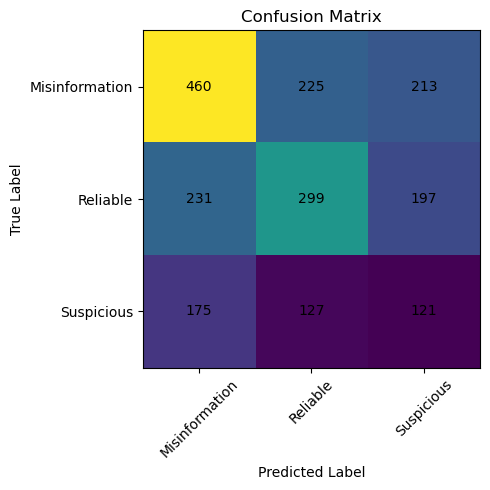

In [11]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(len(labels)), labels, rotation=45)
plt.yticks(range(len(labels)), labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


## 11. Credibility Score + Evidence Report

In [12]:
def sensational_score_simple(text):
    text = str(text)
    sensational_words = [
        "breaking", "shocking", "miracle", "secret", "urgent",
        "must share", "viral", "exposed", "unbelievable"
    ]
    lower_text = text.lower()
    score = sum(1 for word in sensational_words if word in lower_text)
    score += text.count("!")
    return score


def hedging_score_simple(text):
    text = str(text).lower()
    hedging_phrases = [
        "some say", "reportedly", "rumor", "allegedly",
        "experts claim", "it is believed", "may be", "could be"
    ]
    return sum(1 for phrase in hedging_phrases if phrase in text)


def make_input_dataframe(post_text):
    row = {"text": post_text}
    
    # Create numeric columns only if model expects them
    if "sensational_score" in numeric_features:
        row["sensational_score"] = sensational_score_simple(post_text)
    if "hedging_score" in numeric_features:
        row["hedging_score"] = hedging_score_simple(post_text)
    if "sentiment_compound" in numeric_features:
        row["sentiment_compound"] = 0
    if "text_length" in numeric_features:
        row["text_length"] = len(str(post_text))
    if "word_count" in numeric_features:
        row["word_count"] = len(str(post_text).split())
    
    return pd.DataFrame([row])


def generate_evidence(text, predicted_class, credibility_score, confidence):
    evidence = []
    text_lower = str(text).lower()
    
    if sensational_score_simple(text) > 0:
        evidence.append({
            "signal": "sensational_language",
            "description": "The post contains emotional, urgent, or viral-style words."
        })
    
    if hedging_score_simple(text) > 0:
        evidence.append({
            "signal": "uncertain_claim",
            "description": "The post uses uncertain phrases such as reportedly, allegedly, or rumor-like language."
        })
    
    if predicted_class == "Misinformation":
        evidence.append({
            "signal": "model_prediction",
            "description": "The trained classifier predicted the post as misinformation."
        })
    
    if credibility_score < 0.4:
        evidence.append({
            "signal": "low_credibility_score",
            "description": "The credibility score is low based on model probability."
        })
    
    if not evidence:
        evidence.append({
            "signal": "no_strong_warning_signal",
            "description": "No strong misinformation signal was detected by the current model."
        })
    
    return evidence


def predict_post(post_text, post_id="demo_001"):
    input_df = make_input_dataframe(post_text)
    pred_class = model.predict(input_df)[0]
    proba = model.predict_proba(input_df)[0]
    class_names = model.named_steps["classifier"].classes_
    prob_dict = dict(zip(class_names, proba))
    
    confidence = float(np.max(proba))
    reliable_prob = float(prob_dict.get("Reliable", 0.0))
    credibility_score = reliable_prob
    
    report = {
        "post_id": post_id,
        "classification": pred_class,
        "credibility_score": round(credibility_score, 3),
        "confidence": f"{round(confidence * 100, 2)}%",
        "class_probabilities": {k: round(float(v), 3) for k, v in prob_dict.items()},
        "evidence": generate_evidence(post_text, pred_class, credibility_score, confidence)
    }
    
    return report


## 12. Test Prediction

In [13]:
sample_post = "Breaking! Doctors found a miracle cure that the government is hiding. Share urgently!"
report = predict_post(sample_post, post_id="123")
print(json.dumps(report, indent=4))


{
    "post_id": "123",
    "classification": "Reliable",
    "credibility_score": 0.447,
    "confidence": "44.68%",
    "class_probabilities": {
        "Misinformation": 0.398,
        "Reliable": 0.447,
        "Suspicious": 0.155
    },
    "evidence": [
        {
            "signal": "sensational_language",
            "description": "The post contains emotional, urgent, or viral-style words."
        }
    ]
}


## 13. Save Model

In [14]:
os.makedirs("models", exist_ok=True)

model_path = "models/smd_logistic_regression_model.pkl"
joblib.dump(model, model_path)

print("Model saved at:", model_path)


Model saved at: models/smd_logistic_regression_model.pkl


## 14. Load Saved Model Test

In [15]:
loaded_model = joblib.load("models/smd_logistic_regression_model.pkl")
print("Saved model loaded successfully.")
print(loaded_model.predict(pd.DataFrame([{"text": "This is a normal factual statement about a public event."}]))[0])


Saved model loaded successfully.
Reliable


# Next Step

After this notebook runs successfully, create the next notebook/file:

`04_evidence_report_and_app.ipynb` or `app.py`

That file will use the saved model from:

`models/smd_logistic_regression_model.pkl`


In [19]:
import os
import joblib

os.makedirs("models", exist_ok=True)

# Save only trained model
joblib.dump(model, "models/smd_model.pkl")

print("Model saved successfully!")
print(os.listdir("models"))

Model saved successfully!
['smd_logistic_regression_model.pkl', 'smd_model.pkl', 'tfidf_vectorizer.pkl']
